<a href="https://colab.research.google.com/github/naseealavutheen1805/Python-project/blob/main/Naseema_Banu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INTRODUCTION**

This project analyzes an e-commerce dataset to understand sales performance, customer behavior, and operational efficiency. The objective is to identify key insights related to revenue trends, product demand, cancellations, and order fulfillment. The analysis focuses on financial performance, customer insights, logistics, and product management to support data-driven decision-making.

**Import Libraries and file**

In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [211]:
df = pd.read_csv('/content/drive/MyDrive/sales_dataset.csv')


/tmp/ipykernel_7466/4020204073.py:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/sales_dataset.csv')


**Data Understanding**

In [212]:
df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [213]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount              121155 non-null  float64
 15  ship-city           128916 non-nul

In [214]:
df.describe()

,Qty,Amount,ship-postal-code
count,128949.000000,121155.000000,128916.000000
mean,0.904629,648.550806,463978.298008
std,0.314782,281.218324,191473.322953
min,0.000000,0.000000,110001.000000
25%,1.000000,449.000000,382421.000000
50%,1.000000,605.000000,500033.000000
75%,1.000000,788.000000,600024.000000
max,15.000000,5584.000000,989898.000000


In [215]:
df.isnull().sum()


,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


**Data Cleaning**

In [216]:
df.isnull().mean() * 100



,0
Order ID,0.000000
Date,0.000000
Status,0.000000
Fulfilment,0.000000
Sales Channel,0.000000
ship-service-level,0.000000
Style,0.000000
SKU,0.000000
Category,0.000000
Size,0.000000


In [217]:
df.columns = df.columns.str.strip().str.title()

In [218]:
df = df.rename(columns={
    'Order Id': 'Order ID',
    'Fulfilment': 'Fulfillment',
    'Ship-Service-Level': 'Service Level',
    'Ship-Mode': 'Ship Mode',
    'Qty': 'Quantity',
    'Ship-State': 'State',
    'Ship-City': 'City',
    'Ship-Postal-Code': 'Postal Code',
    'Fulfilled-By': 'Fulfilled By',
    'Ship-Country': 'Country',
    'Promotion-Ids': 'Promotion IDs'
})
df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfillment', 'Sales Channel',
       'Service Level', 'Style', 'Sku', 'Category', 'Size', 'Asin',
       'Courier Status', 'Quantity', 'Currency', 'Amount', 'City', 'State',
       'Postal Code', 'Country', 'Promotion IDs', 'B2B', 'Fulfilled By',
       'Unnamed: 22'],
      dtype='object')

In [219]:
df.drop(['Unnamed: 22'], axis=1,inplace = True)
df.drop(['Promotion IDs'], axis=1,inplace = True)
df.drop(['Fulfilled By'], axis=1,inplace = True)


In [220]:
df['City'] = df['City'].fillna('Unknown')
df['State'] = df['State'].fillna('Unknown')
df['Courier Status'] = df['Courier Status'].fillna('Not Available')
df['Country'].fillna(df['Country'].mode()[0], inplace=True)
df['Postal Code'] = df['Postal Code'].fillna(0)
df['Currency'] = df['Currency'].fillna('INR')

/tmp/ipykernel_7466/719942700.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Country'].fillna(df['Country'].mode()[0], inplace=True)


In [221]:
df['Country'] = df['Country'].replace('IN', 'India')

In [223]:
cols = ['Status', 'State', 'City']

df[cols] = df[cols].apply(lambda x: x.str.title())

In [224]:
df['Customer Type'] = df['B2B'].replace({
    True: 'B2B',
    False: 'B2C'
})


In [225]:
df['Status'].unique()

array(['Cancelled', 'Shipped - Delivered To Buyer', 'Shipped',
       'Shipped - Returned To Seller', 'Shipped - Rejected By Buyer',
       'Shipped - Lost In Transit', 'Shipped - Out For Delivery',
       'Shipped - Returning To Seller', 'Shipped - Picked Up', 'Pending',
       'Pending - Waiting For Pick Up', 'Shipped - Damaged', 'Shipping'],
      dtype=object)

In [226]:
df['Status Group'] = df['Status'].replace({
     'Shipped - Delivered To Buyer': 'Delivered',
     'Shipped - Out For Delivery': 'Shipped',
     'Shipped - Picked Up': 'Shipped',
     'Cancelled': 'Cancelled',
     'Shipped - Lost In Transit': 'Cancelled',
     'Shipped - Returned To Seller': 'Returned',
     'Shipped - Returning To Seller': 'Returned',
     'Shipped - Damaged':'Returned',
     'Shipped - Rejected By Buyer': 'Returned',
     'Pending': 'Pending',
     'Pending - Waiting For Pick Up': 'Pending',

})

In [227]:
df['Amount'][df['Status Group'] == 'Cancelled'] = 0
df['Amount'].fillna(df['Amount'].median(), inplace=True)

/tmp/ipykernel_7466/2445262059.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Amount'][df['Status Group'] == 'Cancelled'] = 0
/tmp/ipykernel_7466/2445262059.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

In [228]:
df['Status Group'].value_counts()

,count
Status Group,
Shipped,78775
Delivered,28771
Cancelled,18346
Returned,2110
Pending,939
Shipping,8


In [229]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_7466/2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [230]:
df['Amount'] = df['Amount'].astype('float')
df['Postal Code'] = df['Postal Code'].astype('int')
df['Customer Type'] = df['Customer Type'].astype('category')
df['Status Group'] = df['Status Group'].astype('category')

In [231]:
df['Weekday'] = df['Date'].dt.day_name()
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Month Name'] = df['Date'].dt.strftime('%B')
df['Month Year'] = df['Date'].dt.strftime('%b %Y')

In [232]:
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfillment,0
Sales Channel,0
Service Level,0
Style,0
Sku,0
Category,0
Size,0


In [233]:
df.head(5)

,Order ID,Date,Status,Fulfillment,Sales Channel,Service Level,Style,Sku,Category,Size,...,Country,B2B,Customer Type,Status Group,Weekday,Year,Month,Quarter,Month Name,Month Year
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,India,False,B2C,Cancelled,Saturday,2022,4,2,April,Apr 2022
1,171-9198151-1101146,2022-04-30,Shipped - Delivered To Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,India,False,B2C,Delivered,Saturday,2022,4,2,April,Apr 2022
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,India,True,B2B,Shipped,Saturday,2022,4,2,April,Apr 2022
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,India,False,B2C,Cancelled,Saturday,2022,4,2,April,Apr 2022
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,India,False,B2C,Shipped,Saturday,2022,4,2,April,Apr 2022


In [234]:
df['Country'].unique()

array(['India'], dtype=object)

**Key Metrics**

In [235]:
total_revenue = round(df['Amount'].sum(), 2)
print("Total_revenue:", total_revenue)
total_orders = df['Order ID'].nunique()
print("Total_orders:", total_orders)
total_quantity = df['Quantity'].sum()
print("Total_quantity:", total_quantity )
total_cancellation = (df['Status Group'] == 'Cancelled').sum()
print("Total_cancellation:", total_cancellation)
total_categoriess = df['Category'].nunique()
print("Total_categoriess:", total_categoriess)
total_products = df['Sku'].nunique()
print("Total_products:", total_products)
total_customers = df['Postal Code'].nunique()
print("Total_customers:",total_customers)

Total_revenue: 71772951.62
Total_orders: 120352
Total_quantity: 116651
Total_cancellation: 18346
Total_categoriess: 9
Total_products: 7195
Total_customers: 9460


In [236]:
df['Month Name'].value_counts()

,count
Month Name,
April,49058
May,42035
June,37685
March,171


In [237]:
cancelled_revenue = df[df['Status Group'] == 'Cancelled']['Amount'].sum()
print(cancelled_revenue)
returned_revenue = round(df[df['Status Group'] == 'Returned']['Amount'].sum())
print(returned_revenue)

0.0
1387330


In [238]:
B2B_revenue = round(df[df['Customer Type'] == 'B2B']['Amount'].sum())
print(B2B_revenue)
B2C_revenue = round(df[df['Customer Type'] == 'B2C']['Amount'].sum(), 3)
print(B2C_revenue)
Amazon_Fulfillment = df[df['Fulfillment'] == 'Amazon'].shape[0]
print(Amazon_Fulfillment)
Merchant_Fulfillment = df[df['Fulfillment'] == 'Merchant'].shape[0]
print(Merchant_Fulfillment)

559945
71213006.62
89679
39270


In [239]:
Status_Of_Products = df.groupby('Status Group')['Amount'].sum()
df['Status Group'].value_counts()

/tmp/ipykernel_7466/1041111243.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Status_Of_Products = df.groupby('Status Group')['Amount'].sum()


,count
Status Group,
Shipped,78775
Delivered,28771
Cancelled,18346
Returned,2110
Pending,939
Shipping,8


**Exploratory Data Analysis**

**Financial Performance Analysis**

**Revenue**

In [240]:
Total_revenue = round(df['Amount'].sum(), 2)
print("Total_revenue:", Total_revenue)

Total_revenue: 71772951.62


**Monthly Sales**

In [241]:
month_order = [
     'March', 'April', 'May', 'June'
]


In [242]:
monthly_orders = df.groupby('Month Name')['Order ID'].nunique()
monthly_orders = monthly_orders.reindex(month_order)
print(monthly_orders)

Month Name
March      158
April    45849
May      39216
June     35129
Name: Order ID, dtype: int64


In [243]:
monthly_sales = round(df.groupby('Month Name')['Amount'].sum())
monthly_sales = monthly_sales.reindex(month_order).dropna()
print(monthly_sales)

Month Name
March       95355.0
April    26278570.0
May      23981546.0
June     21417481.0
Name: Amount, dtype: float64


**Monthly Sales Trend**

Text(0.5, 0, 'Month')

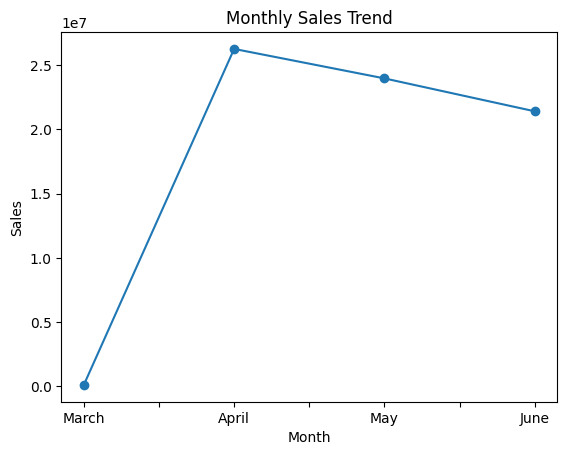

In [244]:
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.xlabel('Month')

**Weekly Sales**

In [245]:
Weekly_sales = round(df.groupby('Weekday')['Amount'].sum()).reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])
print(Weekly_sales)

Weekday
Monday       10300497.0
Tuesday      10491355.0
Wednesday    10316875.0
Thursday      9490909.0
Friday        9861726.0
Saturday     10302683.0
Sunday       11008907.0
Name: Amount, dtype: float64


**Weekly Sales Trend**

<Axes: title={'center': 'Weekly Sales Trend'}, xlabel='Weekday', ylabel='Sales'>

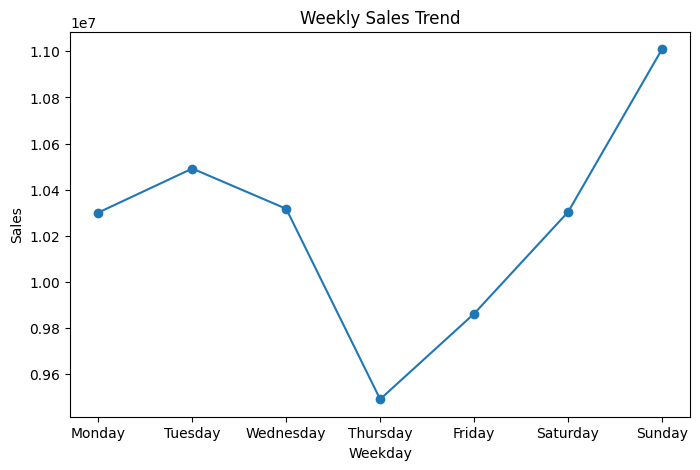

In [246]:
plt.figure(figsize=(8,5))
plt.title('Weekly Sales Trend')
plt.ylabel('Sales')
Weekly_sales.plot(kind='line', marker='o')

**Category Sales**

In [247]:
category_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
print(category_sales)

Category
Set              35778588.14
kurta            19472809.48
Western Dress    10208405.00
Top               4908912.00
Ethnic Dress       732061.00
Blouse             420569.00
Bottom             135998.00
Saree              114694.00
Dupatta               915.00
Name: Amount, dtype: float64


Text(0, 0.5, 'Amount')

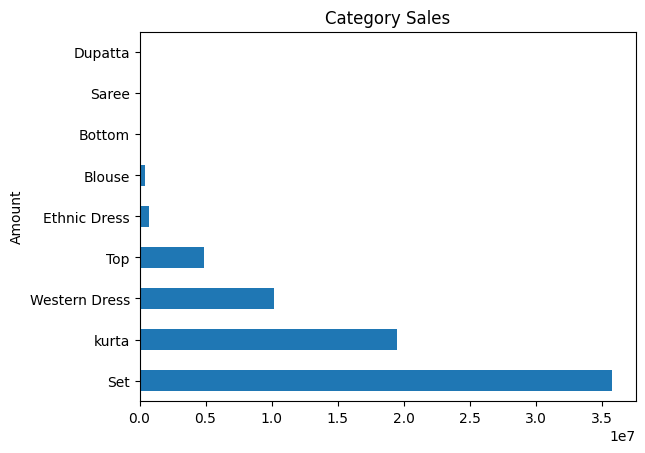

In [248]:
category_sales.plot(kind='barh')
plt.title('Category Sales')
plt.ylabel('Amount')


**AOV**

In [249]:
Avg_order_value = round(Total_revenue / df['Order ID'].nunique())
print("Avg_order_value:", Avg_order_value)

Avg_order_value: 596


**Monthly AOV**

In [250]:
monthly_aov = round(monthly_sales / monthly_orders, 2)
print(monthly_aov)


Month Name
March    603.51
April    573.15
May      611.52
June     609.68
dtype: float64


Text(0.5, 0, 'Month')

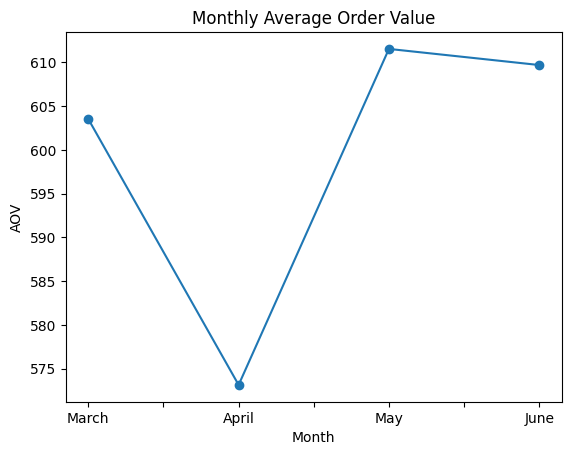

In [251]:
monthly_aov.plot(kind='line', marker='o')
plt.title('Monthly Average Order Value')
plt.ylabel('AOV')
plt.xlabel('Month')

**Customer Insights**

**Top States**

In [252]:
State_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False)
State_sales.head(10)


,Amount
State,
Maharashtra,12234115.00
Karnataka,9647331.00
Telangana,6293653.57
Uttar Pradesh,6185048.00
Tamil Nadu,5958817.00
Delhi,4008240.48
Kerala,3378602.00
West Bengal,3208055.00
Andhra Pradesh,2886567.00


Text(0.5, 1.0, 'Top 10 States by Sales')

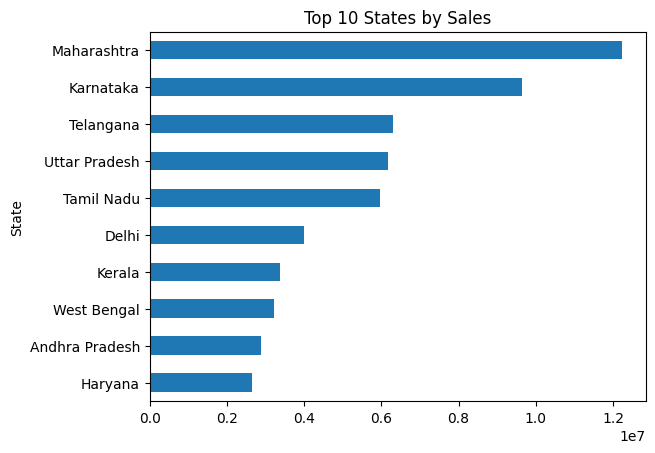

In [253]:
Top_states = State_sales.head(10).sort_values(ascending=True)
Top_states.plot(kind='barh')
plt.title('Top 10 States by Sales')

**Top Cities**

In [254]:
City_sales = df.groupby('City')['Amount'].sum().sort_values(ascending=False)
City_sales.head(10)

,Amount
City,
Bengaluru,6724909.00
Hyderabad,5086559.57
Mumbai,3958055.00
New Delhi,3635853.48
Chennai,3298878.00
Pune,2579907.00
Kolkata,1548256.00
Gurugram,1190848.00
Thane,1016218.00


Text(0.5, 1.0, 'Top 10 Cities by Sales')

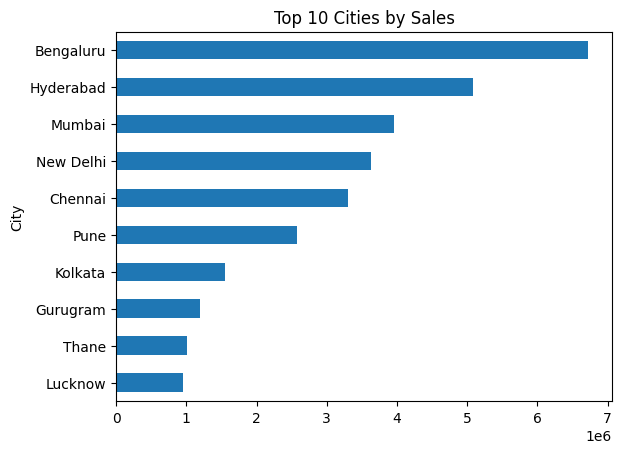

In [255]:
Top_Cities = City_sales.head(10).sort_values(ascending=True)
Top_Cities.plot(kind='barh')
plt.title('Top 10 Cities by Sales')

**Customer Sales**

In [256]:
customer_sales = df.groupby('Customer Type')['Amount'].sum()

/tmp/ipykernel_7466/1791147181.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_sales = df.groupby('Customer Type')['Amount'].sum()


Text(0.5, 1.0, 'Customer Sales by Customer type')

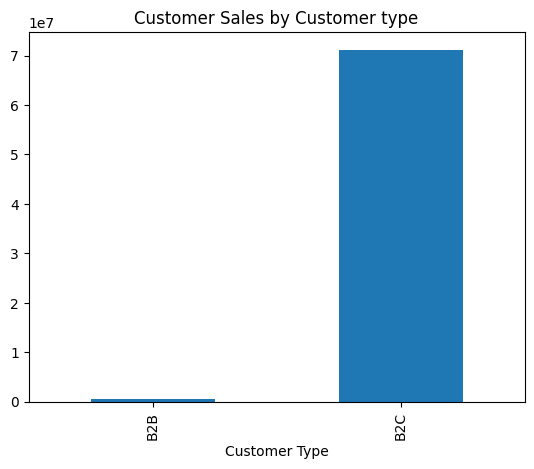

In [257]:
customer_sales.plot(kind='bar')
plt.title('Customer Sales by Customer type')

**Cancellation**

In [258]:
total_cancellation = (df['Status Group'] == 'Cancelled').sum()
print("Total_cancellation:", total_cancellation)

Total_cancellation: 18346


**B2B Vs B2C**

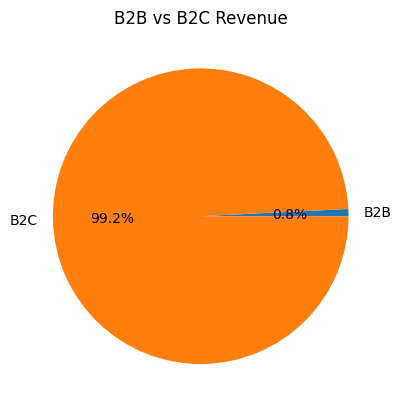

In [259]:
plt.title('B2B vs B2C Revenue')
plt.xticks(rotation=45)
plt.pie(customer_sales.values, labels=customer_sales.index, autopct='%1.1f%%')
plt.show()

**Logistics & Fulfillment Analysis**

In [260]:
df['Fulfillment'].value_counts()

,count
Fulfillment,
Amazon,89679
Merchant,39270


In [261]:
 Fulfillment_sales = df.groupby('Fulfillment')['Amount'].sum()

**Fulfillment Comparison**

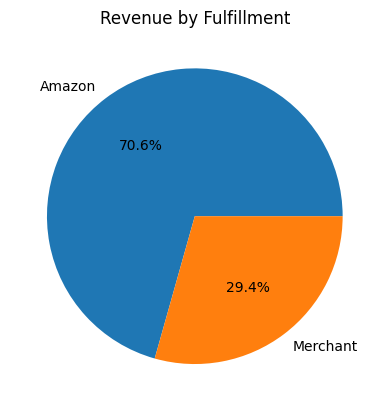

In [262]:
plt.title('Revenue by Fulfillment')
plt.xticks(rotation=45)
plt.pie(Fulfillment_sales.values, labels=Fulfillment_sales.index, autopct='%1.1f%%')
plt.show()

**Courier Status**

<Axes: ylabel='Courier Status'>

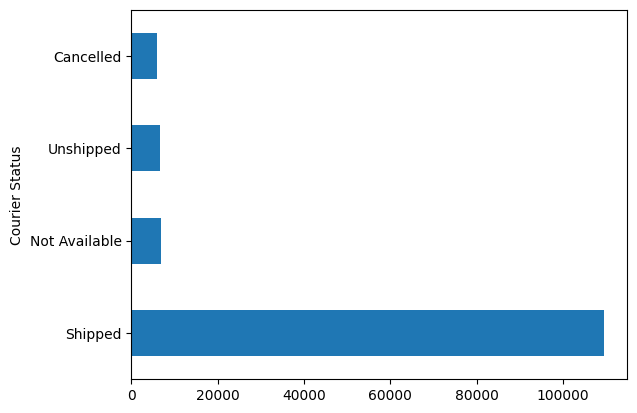

In [263]:
df['Courier Status'].value_counts().plot(kind='barh')

**Shipping Service Level**

Text(0.5, 1.0, 'Service Level')

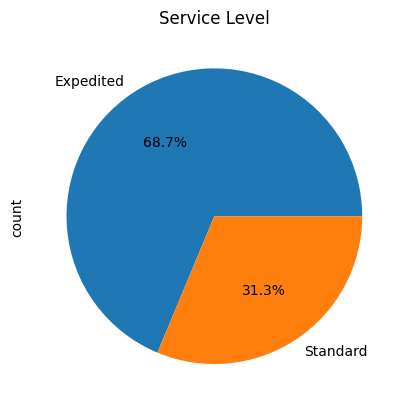

In [264]:
service_level = df['Service Level'].value_counts()
service_level.plot(kind='pie', autopct='%1.1f%%')
plt.title('Service Level')

**Insight: Standard shipping service is used more frequently compared to expedited shipping.**

**Product Management & Inventory**

**Top Category**

In [265]:
df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)

,Quantity
Category,
Set,45288
kurta,45049
Western Dress,13943
Top,9902
Ethnic Dress,1052
Blouse,864
Bottom,398
Saree,152
Dupatta,3


<Axes: title={'center': 'Category Sales'}, ylabel='Category'>

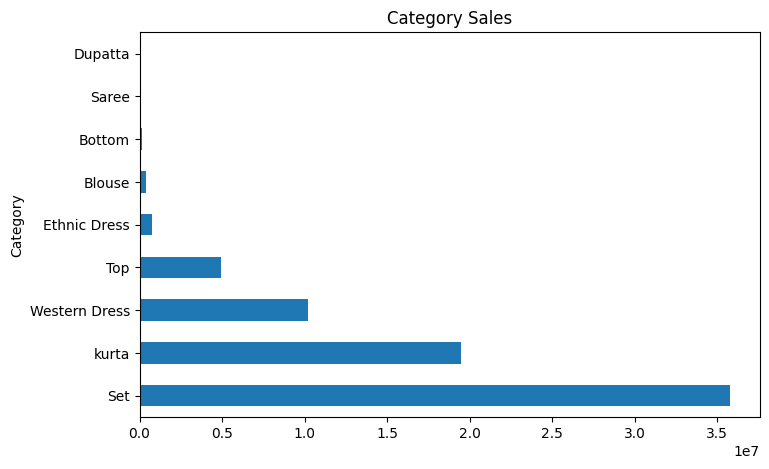

In [266]:
plt.figure(figsize=(8,5))
plt.title('Category Sales')
plt.xlabel('Quantity')
category_sales.plot(kind='barh')

In [267]:
Avg_Quantity = df['Quantity'].mean()
print(Avg_Quantity)

0.9046289618376258


**Product Status**

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Cancelled'),
  Text(1, 0, 'Delivered'),
  Text(2, 0, 'Pending'),
  Text(3, 0, 'Returned'),
  Text(4, 0, 'Shipped'),
  Text(5, 0, 'Shipping')])

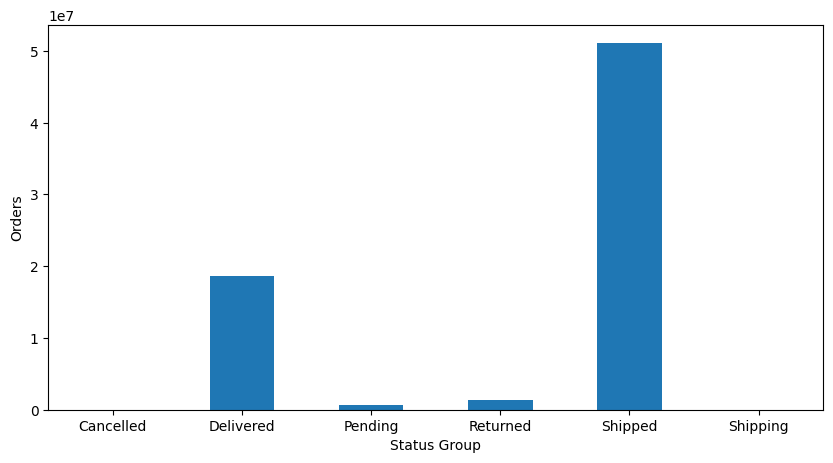

In [268]:
plt.figure(figsize=(10,5))
plt.ylabel('Orders')
Status_Of_Products.plot(kind='bar')
plt.xticks(rotation=0)



**Average Quantity Ordered**

<Axes: ylabel='Category'>

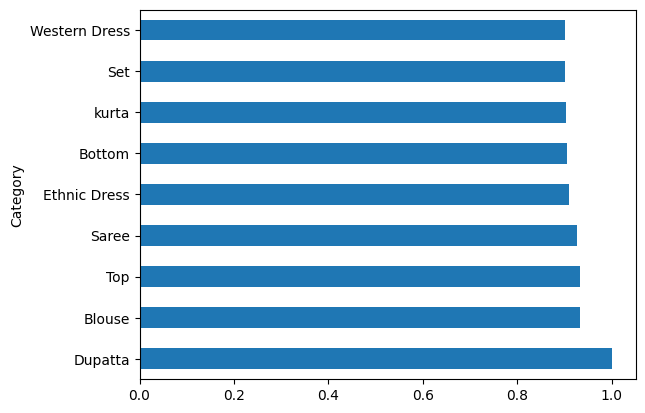

In [269]:
avg_qty = df.groupby('Category')['Quantity'].mean().sort_values(ascending=False)

avg_qty.plot(kind='barh')

**Customer Satisfaction & Returns**

**Total Cancelled Orders**

In [270]:
cancelled_orders = df[df['Status Group'] == 'Cancelled'].groupby('Category')['Order ID'].nunique()
print(cancelled_orders)

Category
Blouse            113
Bottom             54
Ethnic Dress      145
Saree              21
Set              6993
Top              1231
Western Dress    2074
kurta            6823
Name: Order ID, dtype: int64


**Total Cancellation Rate**

In [271]:
cancellation_rate = round((cancelled_orders / total_orders * 100),2).fillna(0).sort_values(ascending=False)
print(cancellation_rate)

Category
Set              5.81
kurta            5.67
Western Dress    1.72
Top              1.02
Ethnic Dress     0.12
Blouse           0.09
Bottom           0.04
Saree            0.02
Name: Order ID, dtype: float64


**Total Cancellation Trend**

<Axes: title={'center': 'Total Cancellation Rate'}, ylabel='Category'>

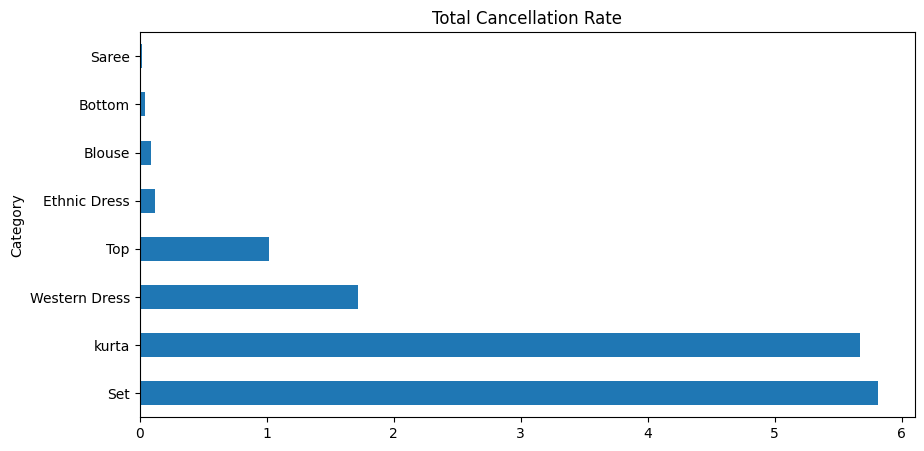

In [272]:
plt.figure(figsize=(10,5))
plt.title('Total Cancellation Rate')
plt.ylabel('Cancellation Rate (%)')
cancellation_rate.plot(kind='barh')

**Monthly Cancelled Orders**

In [273]:
monthly_cancelled = df[df['Status Group'] == 'Cancelled'].groupby('Month Name')['Order ID'].nunique()
monthly_cancelled = monthly_cancelled.reindex(month_order)
print(monthly_cancelled)

Month Name
March      18
April    6732
May      5493
June     4957
Name: Order ID, dtype: int64


**Monthly Cancellation Rate**

In [274]:
monthly_cancellation_rate = round((monthly_cancelled / total_orders) * 100, 2)
print(monthly_cancellation_rate)

Month Name
March    0.01
April    5.59
May      4.56
June     4.12
Name: Order ID, dtype: float64


**Monthly Cancellation Trend**

<Axes: title={'center': 'Monthly Cancellation Trend'}, xlabel='Month Name', ylabel='Cancellation Rate (%)'>

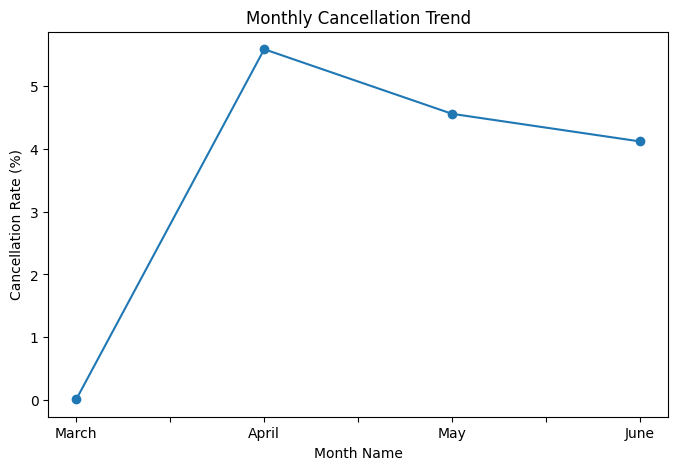

In [275]:
plt.figure(figsize=(8,5))
plt.title('Monthly Cancellation Trend')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Month')
monthly_cancellation_rate.plot(kind='line', marker='o')

**Returned Orders**

In [276]:
returned_orders = df[df['Status Group'] == 'Returned'].groupby('Category')['Order ID'].count()
print(returned_orders)

Category
Blouse            12
Bottom             6
Ethnic Dress      16
Saree              1
Set              845
Top              134
Western Dress    344
kurta            752
Name: Order ID, dtype: int64


**Returned rate(%)**

In [277]:
returned_rate = round((returned_orders / total_orders * 100)).fillna(0).sort_values(ascending=False)
print(returned_rate)

Category
kurta            1.0
Set              1.0
Blouse           0.0
Bottom           0.0
Saree            0.0
Ethnic Dress     0.0
Top              0.0
Western Dress    0.0
Name: Order ID, dtype: float64


<Axes: title={'center': 'Returned Rate by Category'}, ylabel='Category'>

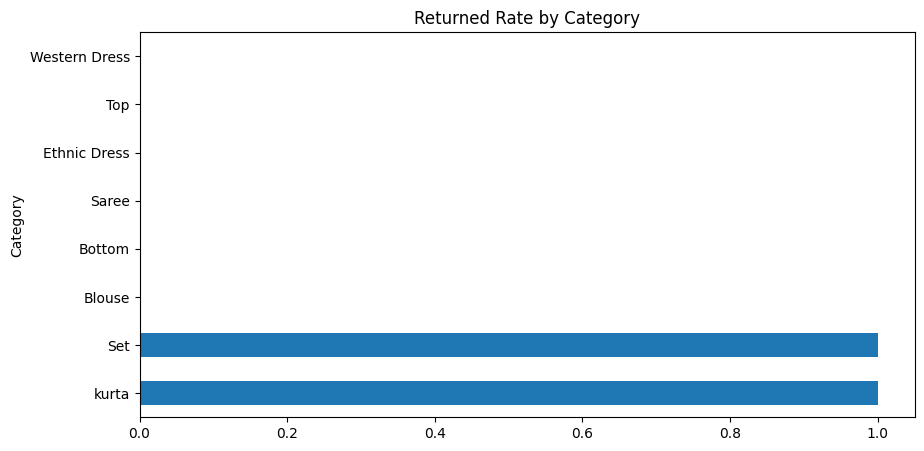

In [278]:
plt.figure(figsize=(10,5))
plt.title('Returned Rate by Category')
plt.ylabel('Return Rate (%)')
returned_rate.plot(kind='barh')

**Problematic Products/Category**

**High Cancellation Rate**

In [279]:
cancellation_rate = round((cancelled_orders / total_orders * 100),2).fillna(0).sort_values(ascending=False)
print(cancellation_rate)

Category
Set              5.81
kurta            5.67
Western Dress    1.72
Top              1.02
Ethnic Dress     0.12
Blouse           0.09
Bottom           0.04
Saree            0.02
Name: Order ID, dtype: float64


<Axes: title={'center': 'Cancellation Rate by category'}, ylabel='Category'>

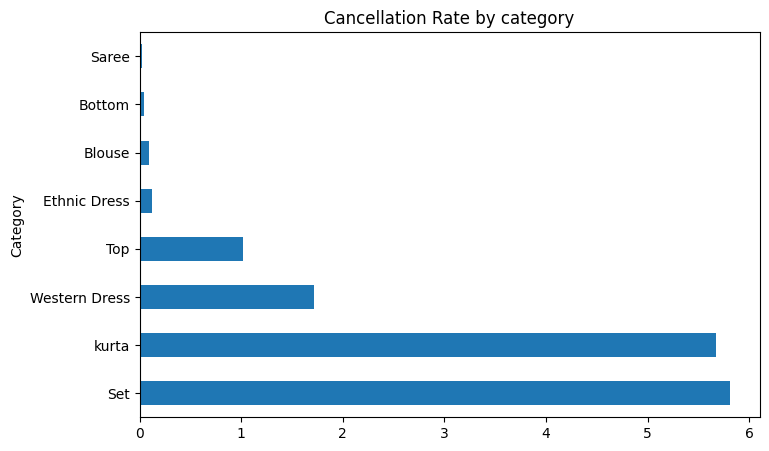

In [280]:
plt.figure(figsize=(8,5))
plt.title('Cancellation Rate by category')
plt.ylabel('Cancellation rate (%)')
cancellation_rate.plot(kind='barh')

**High Returned Rate**

In [281]:
returned_rate = round((returned_orders / total_orders * 100)).fillna(0).sort_values(ascending=False)
print(returned_rate)

Category
kurta            1.0
Set              1.0
Blouse           0.0
Bottom           0.0
Saree            0.0
Ethnic Dress     0.0
Top              0.0
Western Dress    0.0
Name: Order ID, dtype: float64


<Axes: title={'center': 'Returned Rate by Category'}, ylabel='Category'>

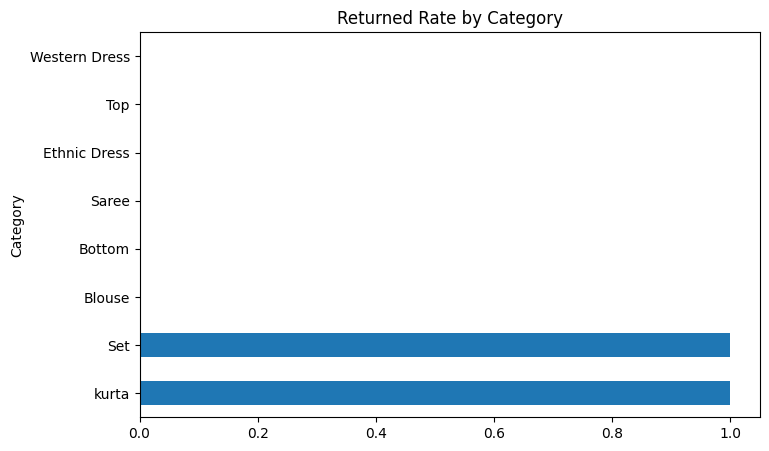

In [282]:
plt.figure(figsize=(8,5))
plt.title('Returned Rate by Category')
plt.ylabel('Return Rate (%)')
returned_rate.plot(kind='barh')

**Set and Kurta categories show relatively higher cancellation and return rates, indicating possible issues related to customer expectations, product quality, or fulfillment.**

**Conclusion**:
  The analysis provided valuable insights into sales performance, customer behavior, product demand, and operational efficiency within the e-commerce business. The study identified May as the highest revenue-generating month, while the Set category emerged as the top-performing product segment. Maharashtra recorded the highest sales contribution, and certain categories showed relatively higher cancellation and return rates. Overall, the findings highlight opportunities to improve inventory planning, fulfillment processes, and customer satisfaction through data-driven decision-making.

**Key Insights & Business Recommendations**

**Key Insights**
1.  FINANCIAL: April recorded the highest revenue among all months, indicating
strong customer demand during this period.
2. TOP CATEGORY: Set emerged as the highest revenue-generating and best-selling product category.

3.  TOP STATE: Maharashtra contributed the highest number of orders and overall sales across all states.
4. B2B vs B2C: B2C customers contributed higher overall order value, making them the primary revenue-driving customer segment.


5. CANCELLATION: Saree category recorded the highest cancellation rate at 14.69%, indicating possible issues related to customer expectations or product quality.
6.  FULFILLMENT: Merchant fulfillment handled a larger share of orders compared to Amazon fulfillment.










**Business Recommendation**
*   Improve quality checks for high-return categories such as Set and Kurta
*   Enhance courier tracking systems to reduce missing shipment updates
*   Focus inventory planning on high-demand product categories
*   Increase marketing efforts in top-performing cities and states
*   Monitor cancellation trends regularly to improve fulfillment efficiency




